# Phase 1: Understanding the Problem

- **Business Impact of Employee Performance**

Employee performance is a cornerstone of organizational success. Strong performance boosts productivity, innovation, customer satisfaction, and profitability, while weak performance can trigger attrition, delays, and higher costs. By analyzing performance data, HR teams can design targeted training, improve retention, and allocate resources more effectively—ultimately strengthening workforce stability and driving growth.


- **Key Variables in the Dataset**
- **Demographics:** Age, Gender, MaritalStatus, EducationBackground
- **Job-related:** EmpDepartment, EmpJobRole, BusinessTravelFrequency, DistanceFromHome
- **Satisfaction and Engagement:** EmpEnvironmentSatisfaction, EmpJobSatisfaction, EmpRelationshipSatisfaction, EmpWorkLifeBalance
- **Performance Indicators:** Attrition, PerformanceRating, EmpLastSalaryHikePercent
- **Experience and Career Progression:** NumCompaniesWorked, TotalWorkExperienceInYears, ExperienceYearsAtThisCompany, YearsSinceLastPromotion
- **Compensation and Work Conditions:** EmpHourlyRate, OverTime


# Phase 2: Exploratory Data Analysis (EDA)

#      Setup and Libraries


In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report
from sklearn.impute import SimpleImputer

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
import xgboost as xgb

import shap

## Phase 2: Load and Inspect Dataset


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
Emp_pef = pd.read_csv("/content/drive/MyDrive/Employee_Peformance_Prediction/Employee_Performance.csv")
Emp_pef.head(10)

,EmpNumber,Age,Gender,EducationBackground,MaritalStatus,EmpDepartment,EmpJobRole,BusinessTravelFrequency,DistanceFromHome,EmpEducationLevel,...,EmpRelationshipSatisfaction,TotalWorkExperienceInYears,TrainingTimesLastYear,EmpWorkLifeBalance,ExperienceYearsAtThisCompany,ExperienceYearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,Attrition,PerformanceRating
0,E1001000,32,Male,Marketing,Single,Sales,Sales Executive,Travel_Rarely,10,3,...,4,10,2,2,10,7,0,8,No,3
1,E1001006,47,Male,Marketing,Single,Sales,Sales Executive,Travel_Rarely,14,4,...,4,20,2,3,7,7,1,7,No,3
2,E1001007,40,Male,Life Sciences,Married,Sales,Sales Executive,Travel_Frequently,5,4,...,3,20,2,3,18,13,1,12,No,4
3,E1001009,41,Male,Human Resources,Divorced,Human Resources,Manager,Travel_Rarely,10,4,...,2,23,2,2,21,6,12,6,No,3
4,E1001010,60,Male,Marketing,Single,Sales,Sales Executive,Travel_Rarely,16,4,...,4,10,1,3,2,2,2,2,No,3
5,E1001011,27,Male,Life Sciences,Divorced,Development,Developer,Travel_Frequently,10,2,...,3,9,4,2,9,7,1,7,No,4
6,E1001016,50,Male,Marketing,Married,Sales,Sales Representative,Travel_Rarely,8,4,...,4,4,2,3,2,2,2,2,No,3
7,E1001019,28,Female,Life Sciences,Single,Development,Developer,Travel_Rarely,1,2,...,4,10,4,3,7,7,3,7,Yes,3
8,E1001020,36,Female,Life Sciences,Married,Development,Developer,Non-Travel,8,3,...,1,10,2,3,8,7,0,5,No,3
9,E1001021,38,Female,Life Sciences,Single,Development,Developer,Travel_Rarely,1,3,...,4,10,4,4,1,0,0,0,No,3


In [4]:
# data shape
Emp_pef.shape


(1200, 28)

In [5]:
# gets quick info about the data
Emp_pef.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 28 columns):
 #   Column                        Non-Null Count  Dtype 
---  ------                        --------------  ----- 
 0   EmpNumber                     1200 non-null   object
 1   Age                           1200 non-null   int64 
 2   Gender                        1200 non-null   object
 3   EducationBackground           1200 non-null   object
 4   MaritalStatus                 1200 non-null   object
 5   EmpDepartment                 1200 non-null   object
 6   EmpJobRole                    1200 non-null   object
 7   BusinessTravelFrequency       1200 non-null   object
 8   DistanceFromHome              1200 non-null   int64 
 9   EmpEducationLevel             1200 non-null   int64 
 10  EmpEnvironmentSatisfaction    1200 non-null   int64 
 11  EmpHourlyRate                 1200 non-null   int64 
 12  EmpJobInvolvement             1200 non-null   int64 
 13  EmpJobLevel       

In [6]:
# Descriptive statistics
Emp_pef.describe(include='all')

,EmpNumber,Age,Gender,EducationBackground,MaritalStatus,EmpDepartment,EmpJobRole,BusinessTravelFrequency,DistanceFromHome,EmpEducationLevel,...,EmpRelationshipSatisfaction,TotalWorkExperienceInYears,TrainingTimesLastYear,EmpWorkLifeBalance,ExperienceYearsAtThisCompany,ExperienceYearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,Attrition,PerformanceRating
count,1200,1200.000000,1200,1200,1200,1200,1200,1200,1200.000000,1200.00000,...,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200,1200.000000
unique,1200,NaN,2,6,3,6,19,3,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,NaN
top,E100967,NaN,Male,Life Sciences,Married,Sales,Sales Executive,Travel_Rarely,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,No,NaN
freq,1,NaN,725,492,548,373,270,846,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1022,NaN
mean,NaN,36.918333,NaN,NaN,NaN,NaN,NaN,NaN,9.165833,2.89250,...,2.725000,11.330000,2.785833,2.744167,7.077500,4.291667,2.194167,4.105000,NaN,2.948333
std,NaN,9.087289,NaN,NaN,NaN,NaN,NaN,NaN,8.176636,1.04412,...,1.075642,7.797228,1.263446,0.699374,6.236899,3.613744,3.221560,3.541576,NaN,0.518866
min,NaN,18.000000,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,1.00000,...,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,NaN,2.000000
25%,NaN,30.000000,NaN,NaN,NaN,NaN,NaN,NaN,2.000000,2.00000,...,2.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000,NaN,3.000000
50%,NaN,36.000000,NaN,NaN,NaN,NaN,NaN,NaN,7.000000,3.00000,...,3.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000,NaN,3.000000
75%,NaN,43.000000,NaN,NaN,NaN,NaN,NaN,NaN,14.000000,4.00000,...,4.000000,15.000000,3.000000,3.000000,10.000000,7.000000,3.000000,7.000000,NaN,3.000000


In [7]:
# Missing values
Emp_pef.isnull().sum()

,0
EmpNumber,0
Age,0
Gender,0
EducationBackground,0
MaritalStatus,0
EmpDepartment,0
EmpJobRole,0
BusinessTravelFrequency,0
DistanceFromHome,0
EmpEducationLevel,0


In [9]:
#checking for duplicates
Emp_pef.duplicated().sum()

np.int64(0)

In [10]:
#checking for all columns
print(Emp_pef.columns)

Index(['EmpNumber', 'Age', 'Gender', 'EducationBackground', 'MaritalStatus',
       'EmpDepartment', 'EmpJobRole', 'BusinessTravelFrequency',
       'DistanceFromHome', 'EmpEducationLevel', 'EmpEnvironmentSatisfaction',
       'EmpHourlyRate', 'EmpJobInvolvement', 'EmpJobLevel',
       'EmpJobSatisfaction', 'NumCompaniesWorked', 'OverTime',
       'EmpLastSalaryHikePercent', 'EmpRelationshipSatisfaction',
       'TotalWorkExperienceInYears', 'TrainingTimesLastYear',
       'EmpWorkLifeBalance', 'ExperienceYearsAtThisCompany',
       'ExperienceYearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager', 'Attrition', 'PerformanceRating'],
      dtype='object')


## Visualization of Key Relationships

### 1. Attrition vs JobSatisfaction (Bar Chart)
- Purpose: This Shows how job satisfaction levels relate to employee attrition.
- Insight: High attrition among low-satisfaction employees signals retention issues.


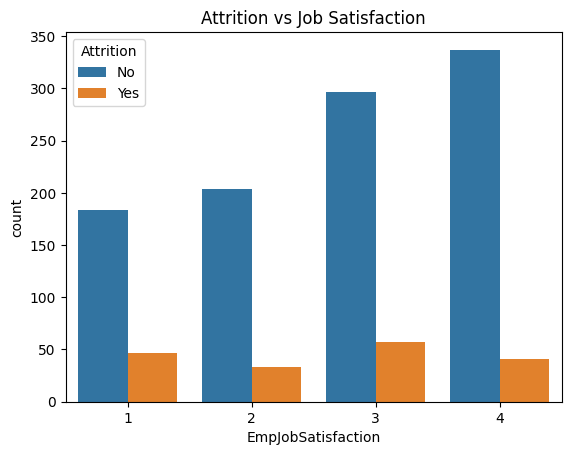

In [11]:
sns.countplot(x="EmpJobSatisfaction", hue="Attrition", data=Emp_pef)
plt.title("Attrition vs Job Satisfaction")
plt.show()

#### 2. Age Distribution (Histogram)
- Purpose: This displays the age spread of employees.
- Insight: It helps in Identifying dominant age groups and potential generational workforce trends.

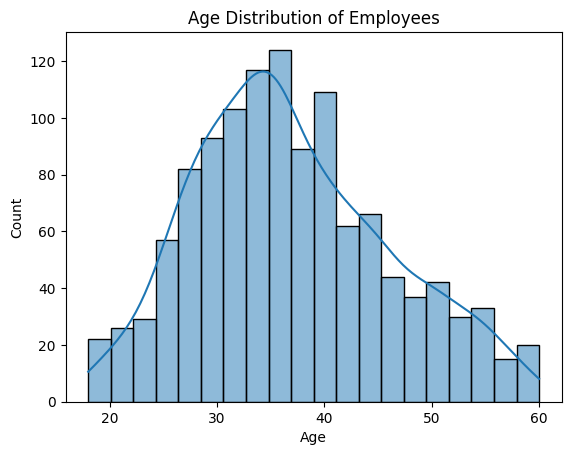

In [12]:
sns.histplot(Emp_pef["Age"], bins=20, kde=True)
plt.title("Age Distribution of Employees")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

### 3. Correlation Heatmap (Numeric Features)
- Purpose: Highlights correlations among numeric variables (e.g., salary hike, years of experience).
- Insight: Detects multicollinearity and strong relationships useful for modeling.

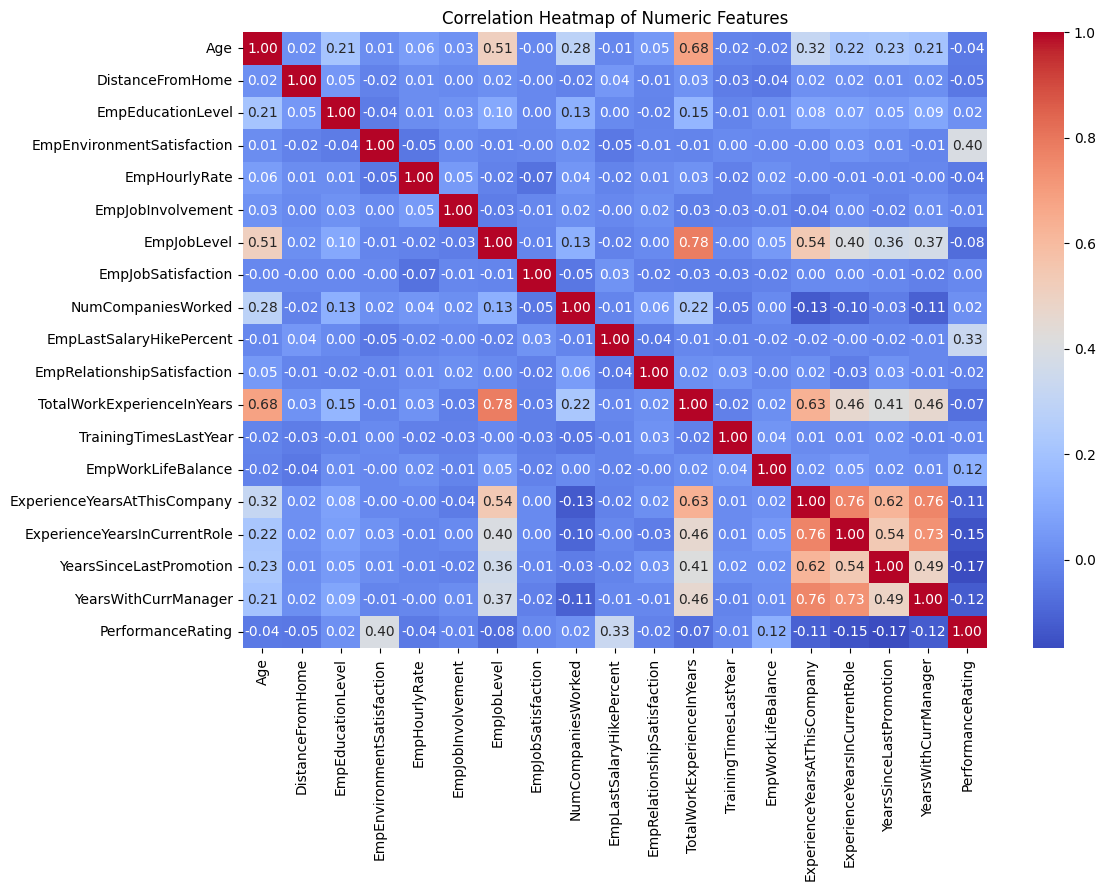

In [13]:
corr = Emp_pef.corr(numeric_only=True)
plt.figure(figsize=(12,8))
sns.heatmap(corr, cmap="coolwarm", annot=True, fmt=".2f")
plt.title("Correlation Heatmap of Numeric Features")
plt.show()

## Key Insights from This Heatmap
- Age vs. TotalWorkExperienceInYears (0.68):
- Older employees tend to have more total work experience — intuitive and expected.
- TotalWorkExperienceInYears vs. ExperienceYearsAtThisCompany (0.78): Strong correlation, meaning employees with longer careers often stay longer in the same company.
- ExperienceYearsAtThisCompany vs. YearsWithCurrManager (0.71):
Suggests tenure at the company is closely tied to tenure with the
same manager.
- Job Level vs. Age/Experience: Higher job levels tend to correlate positively with age and experience, reflecting career progression.
- Weak correlations: Variables like DistanceFromHome, HourlyRate, or TrainingTimesLastYear show little to no correlation with most others — meaning they vary independently.

### 4. SalaryHikePercent vs PerformanceRating (Boxplot)
- Purpose: Compares salary hike percentages across performance ratings.
- Insight: Reveals fairness or bias in compensation relative to performance.


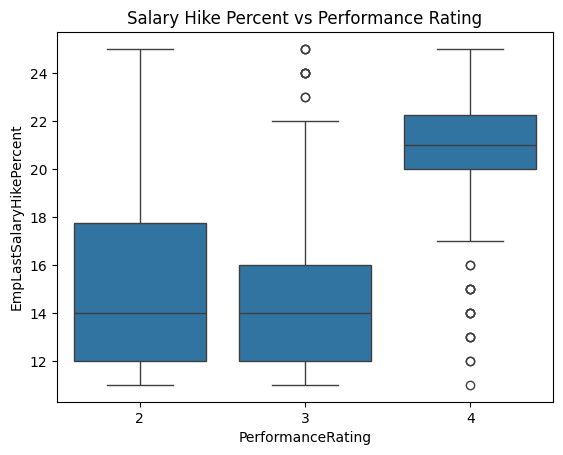

In [14]:
sns.boxplot(x="PerformanceRating", y="EmpLastSalaryHikePercent", data=Emp_pef)
plt.title("Salary Hike Percent vs Performance Rating")
plt.show()

# Phase 3: Preprocessing

In [15]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report
from sklearn.impute import SimpleImputer

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
import xgboost as xgb

import shap

# Separate features and target
X = Emp_pef.drop(["PerformanceRating", "EmpNumber"], axis=1)   # Drop EmpNumber and PerformanceRating
y = Emp_pef["PerformanceRating"]
y = y - y.min() # Adjust target to be 0-indexed for models like XGBoost

# Identify categorical and numerical features
categorical_features = X.select_dtypes(include=["object"]).columns
numerical_features = X.select_dtypes(include=["int64","float64"]).columns

# Preprocessing pipelines
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numerical_features),
        ("cat", categorical_transformer, categorical_features)
    ])

In [16]:
print(categorical_features)

Index(['Gender', 'EducationBackground', 'MaritalStatus', 'EmpDepartment',
       'EmpJobRole', 'BusinessTravelFrequency', 'OverTime', 'Attrition'],
      dtype='object')


In [17]:
print(numerical_features)

Index(['Age', 'DistanceFromHome', 'EmpEducationLevel',
       'EmpEnvironmentSatisfaction', 'EmpHourlyRate', 'EmpJobInvolvement',
       'EmpJobLevel', 'EmpJobSatisfaction', 'NumCompaniesWorked',
       'EmpLastSalaryHikePercent', 'EmpRelationshipSatisfaction',
       'TotalWorkExperienceInYears', 'TrainingTimesLastYear',
       'EmpWorkLifeBalance', 'ExperienceYearsAtThisCompany',
       'ExperienceYearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager'],
      dtype='object')


# # Phase 4: Feature Engineering

In [18]:
# Example derived metrics
Emp_pef["TenureRatio"] = Emp_pef["ExperienceYearsAtThisCompany"] / (Emp_pef["TotalWorkExperienceInYears"]+1)
Emp_pef["PromotionGap"] = Emp_pef["YearsSinceLastPromotion"] / (Emp_pef["TotalWorkExperienceInYears"]+1)

# Update X with engineered features, ensuring 'EmpNumber' is dropped
X = Emp_pef.drop(["PerformanceRating", "EmpNumber"], axis=1)

# Phase 5: Models Training

# Random Forest Model

In [19]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

rf_model = {
    "Random Forest": RandomForestClassifier(random_state=42)
}

for name, model in rf_model.items():
    rf_model = Pipeline(steps=[("preprocessor", preprocessor),
                          ("classifier", model)])


In [20]:
rf_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['Age', 'DistanceFromHome', 'EmpEducationLevel',
       'EmpEnvironmentSatisfaction', 'EmpHourlyRate', 'EmpJobInvolvement',
       'EmpJobLevel', 'EmpJobSatisfaction', 'NumCompaniesWorked',
       'EmpLastSalaryH...
      dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  Index(['Gender', 'EducationBackground', 'MaritalStatus', 'EmpDepartment',
       'EmpJobRole', 'BusinessTravelFrequency', 'OverTime', 'Attrition'],
      dtype='object'))])),
                ('classifier', RandomForestClassifier(random_state=42))])

In [21]:
# Evaluate on validation set
val_acc = rf_model.score(X_test, y_test)
print("Test Accuracy:", val_acc)

Test Accuracy: 0.8958333333333334


In [22]:
y_pred = rf_model.predict(X_test)

In [23]:
print(f"\n{name} Results:")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, average="macro"))
print("Recall:", recall_score(y_test, y_pred, average="macro"))
print("F1 Score:", f1_score(y_test, y_pred, average="macro"))
print(classification_report(y_test, y_pred))


Random Forest Results:
Accuracy: 0.8958333333333334
Precision: 0.9309493127147767
Recall: 0.754969474969475
F1 Score: 0.8163835769813096
              precision    recall  f1-score   support

           0       0.91      0.74      0.82        39
           1       0.89      0.98      0.93       175
           2       1.00      0.54      0.70        26

    accuracy                           0.90       240
   macro avg       0.93      0.75      0.82       240
weighted avg       0.90      0.90      0.89       240



The Random Forest model achieved a test accuracy of 90.8% on the employee performance prediction task. This means the model correctly predicted the performance rating for approximately 90.82% of the test data.


 # Cross-validation

In [24]:
cv_scores = cross_val_score(rf_model, X_train, y_train, cv=5)
print("CV Mean Accuracy:", cv_scores.mean())


CV Mean Accuracy: 0.8947916666666667


The accuracy reduced to 89.5%

I perform Permutation tests to help validate whether my model’s performance is significantly better than chance.

## Permutation Tests

In [25]:
from sklearn.model_selection import permutation_test_score

# Example with Random Forest
rf_model = Pipeline(steps=[("preprocessor", preprocessor),
                         ("classifier", RandomForestClassifier(random_state=42))])

score, perm_scores, pvalue = permutation_test_score(
    rf_model, X_train, y_train, cv=5, n_permutations=100, scoring="accuracy"
)

print("Permutation Test Accuracy:", score)
print("Permutation Test p-value:", pvalue)

Permutation Test Accuracy: 0.8947916666666667
Permutation Test p-value: 0.009900990099009901


- My tuned model is highly accurate (≈90%).
- The low p‑value (<0.05) confirms the performance is not random — the model is valid and reliable.
- This is strong evidence that my chosen features and tuned algorithm are capturing meaningful relationships in employee performance ratings.


## Hyperparameter Tuning

In [26]:
param_dist_rf = {
    "classifier__n_estimators": [100, 200, 300, 400],
    "classifier__max_depth": [None, 10, 20, 30],
    "classifier__min_samples_split": [2, 5, 10],
    "classifier__min_samples_leaf": [1, 2, 4],
    "classifier__bootstrap": [True, False]
}

rand_rf = RandomizedSearchCV(
    Pipeline([("preprocessor", preprocessor),
              ("classifier", RandomForestClassifier(random_state=42))]),
    param_distributions=param_dist_rf,
    n_iter=30, cv=5, scoring="accuracy", random_state=42
)

rand_rf.fit(X_train, y_train)
print("Best Random Forest Params:", rand_rf.best_params_)

Best Random Forest Params: {'classifier__n_estimators': 300, 'classifier__min_samples_split': 5, 'classifier__min_samples_leaf': 1, 'classifier__max_depth': 20, 'classifier__bootstrap': False}


In [27]:
# Get the best pipeline (preprocessor + classifier) from RandomizedSearchCV
best_rf_pipeline = rand_rf.best_estimator_

# Predict on the test set (using X_test instead of X_val)
y_pred_best = best_rf_pipeline.predict(X_test)

# Evaluate accuracy (using y_test instead of y_val)
print("Tuned Random Forest Accuracy:", accuracy_score(y_test, y_pred_best))
print("Classification Report for Tuned Random Forest:\n", classification_report(y_test, y_pred_best))

Tuned Random Forest Accuracy: 0.925
Classification Report for Tuned Random Forest:
               precision    recall  f1-score   support

           0       0.91      0.82      0.86        39
           1       0.92      0.98      0.95       175
           2       1.00      0.69      0.82        26

    accuracy                           0.93       240
   macro avg       0.94      0.83      0.88       240
weighted avg       0.93      0.93      0.92       240



The accuracy of the model increased to ≈93% accuracy after the hyperparameter tuning.

In [28]:
best_rf_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['Age', 'DistanceFromHome', 'EmpEducationLevel',
       'EmpEnvironmentSatisfaction', 'EmpHourlyRate', 'EmpJobInvolvement',
       'EmpJobLevel', 'EmpJobSatisfaction', 'NumCompaniesWorked',
       'EmpLastSalaryH...
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  Index(['Gender', 'EducationBackground', 'MaritalStatus', 'EmpDepartment',
       'EmpJobRole', 'BusinessTravelFrequency', 'OverTime', 'Attrition'],
      dtype='object'))])),
                ('classifier',
                 RandomForestClassifier(bootstrap=False, max_depth=20,
                                        min_samples_split=5, n_estimators=300,
                                        random_state=42))])

# Logistic Regression

In [29]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "XGBoost": xgb.XGBClassifier(use_label_encoder=False, eval_metric="mlogloss", random_state=42)
}

In [30]:
# Training and Evaluating Logistic Regression
lr_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000))
])
lr_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['Age', 'DistanceFromHome', 'EmpEducationLevel',
       'EmpEnvironmentSatisfaction', 'EmpHourlyRate', 'EmpJobInvolvement',
       'EmpJobLevel', 'EmpJobSatisfaction', 'NumCompaniesWorked',
       'EmpLastSalaryH...
       'YearsWithCurrManager'],
      dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  Index(['Gender', 'EducationBackground', 'MaritalStatus', 'EmpDepartment',
       'EmpJobRole', 'BusinessTravelFrequency', 'OverTime', 'Attrition'],
      dtype='object'))])),
                ('classifier', LogisticRegression(max_iter=1000))])

In [31]:
y_pred_lr = lr_model.predict(X_test)

print("Logistic Regression Results:")
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("Precision:", precision_score(y_test, y_pred_lr, average="macro"))
print("Recall:", recall_score(y_test, y_pred_lr, average="macro"))
print("F1 Score:", f1_score(y_test, y_pred_lr, average="macro"))
print(classification_report(y_test, y_pred_lr))

Logistic Regression Results:
Accuracy: 0.825
Precision: 0.7709677419354839
Recall: 0.6779975579975579
F1 Score: 0.7157063129665869
              precision    recall  f1-score   support

           0       0.61      0.49      0.54        39
           1       0.86      0.93      0.89       175
           2       0.84      0.62      0.71        26

    accuracy                           0.82       240
   macro avg       0.77      0.68      0.72       240
weighted avg       0.82      0.82      0.82       240



The accuracy of Logistic Regression of ≈84% matches the result of the hyperparameter tunning

## Gradient Boosting Model (gbc)
I also try Gradient Boosting to see if there will be a variation in the accuracy score

In [32]:
gbc_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", GradientBoostingClassifier(random_state=42))
])

gbc_model.fit(X_train, y_train)


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['Age', 'DistanceFromHome', 'EmpEducationLevel',
       'EmpEnvironmentSatisfaction', 'EmpHourlyRate', 'EmpJobInvolvement',
       'EmpJobLevel', 'EmpJobSatisfaction', 'NumCompaniesWorked',
       'EmpLastSalaryH...
      dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  Index(['Gender', 'EducationBackground', 'MaritalStatus', 'EmpDepartment',
       'EmpJobRole', 'BusinessTravelFrequency', 'OverTime', 'Attrition'],
      dtype='object'))])),
                ('classifier', GradientBoostingClassifier(random_state=42))])

In [33]:
# Predict with Gradient Boosting model
y_pred_gbc = gbc_model.predict(X_test)

print("Gradient Boosting Results:")
print("Accuracy:", accuracy_score(y_test, y_pred_gbc))
print("Precision:", precision_score(y_test, y_pred_gbc, average="macro"))
print("Recall:", recall_score(y_test, y_pred_gbc, average="macro"))
print("F1 Score:", f1_score(y_test, y_pred_gbc, average="macro"))
print(classification_report(y_test, y_pred_gbc))

Gradient Boosting Results:
Accuracy: 0.9291666666666667
Precision: 0.9134031067732725
Recall: 0.8622710622710623
F1 Score: 0.8856035219133979
              precision    recall  f1-score   support

           0       0.89      0.85      0.87        39
           1       0.94      0.97      0.96       175
           2       0.91      0.77      0.83        26

    accuracy                           0.93       240
   macro avg       0.91      0.86      0.89       240
weighted avg       0.93      0.93      0.93       240



Gradient Boosting gives Accuracy of 93%

## Hyperparameter Tuning

In [34]:
from sklearn.model_selection import RandomizedSearchCV

# Define the pipeline
gbc_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", GradientBoostingClassifier(random_state=42))
])

# Define parameter distributions for Gradient Boosting
param_dist_gb = {
    "classifier__n_estimators": [100, 200, 300, 400],
    "classifier__learning_rate": [0.01, 0.05, 0.1, 0.2],
    "classifier__max_depth": [3, 5, 7],
    "classifier__subsample": [0.8, 1.0],
    "classifier__max_features": ["sqrt", "log2", None]
}

# RandomizedSearchCV setup
rand_gb = RandomizedSearchCV(
    gbc_model,
    param_distributions=param_dist_gb,
    n_iter=25,                # number of random combinations to try = 25
    cv=5,                     # 5-fold cross-validation
    scoring="accuracy",       # or "f1_macro" to check class imbalance
    random_state=42,
    n_jobs=-1                 # use all cores for speed
)


In [35]:
# Fit the tuned model
rand_gb.fit(X_train, y_train)

RandomizedSearchCV(cv=5,
                   estimator=Pipeline(steps=[('preprocessor',
                                              ColumnTransformer(transformers=[('num',
                                                                               Pipeline(steps=[('imputer',
                                                                                                SimpleImputer(strategy='median')),
                                                                                               ('scaler',
                                                                                                StandardScaler())]),
                                                                               Index(['Age', 'DistanceFromHome', 'EmpEducationLevel',
       'EmpEnvironmentSatisfaction', 'EmpHourlyRate', 'EmpJobInvolvement',
       'EmpJobLevel', 'EmpJobSatisfaction', 'N...
      dtype='object'))])),
                                             ('classifier',
                                              GradientBoostingClassifier(random_state=42))]),
                   n_iter=25, n_jobs=-1,
                   param_distributions={'classifier__learning_rate': [0.01,
                                                                      0.05, 0.1,
                                                                      0.2],
                                        'classifier__max_depth': [3, 5, 7],
                                        'classifier__max_features': ['sqrt',
                                                                     'log2',
                                                                     None],
                                        'classifier__n_estimators': [100, 200,
                                                                     300, 400],
                                        'classifier__subsample': [0.8, 1.0]},
                   random_state=42, scoring='accuracy')

In [36]:
# Best parameters
print("Best Gradient Boosting Params:", rand_gb.best_params_)

# Evaluate on test set
y_pred = rand_gb.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, average="macro"))
print("Recall:", recall_score(y_test, y_pred, average="macro"))
print("F1 Score:", f1_score(y_test, y_pred, average="macro"))


Best Gradient Boosting Params: {'classifier__subsample': 0.8, 'classifier__n_estimators': 400, 'classifier__max_features': None, 'classifier__max_depth': 7, 'classifier__learning_rate': 0.2}
Accuracy: 0.9291666666666667
Precision: 0.9186182669789228
Recall: 0.8513553113553113
F1 Score: 0.8812726336225682


- The tuned Gradient Boosting gives Accuracy score of 93%

## XGB Model
Checking if the XGBoost model gives a higher accuracy score.

In [37]:
# Define XGBoost pipeline
xgb_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", xgb.XGBClassifier(
        eval_metric="mlogloss",
        random_state=42
    ))
])

# Fit the pipeline with encoded labels
xgb_model.fit(X_train, y_train)



Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['Age', 'DistanceFromHome', 'EmpEducationLevel',
       'EmpEnvironmentSatisfaction', 'EmpHourlyRate', 'EmpJobInvolvement',
       'EmpJobLevel', 'EmpJobSatisfaction', 'NumCompaniesWorked',
       'EmpLastSalaryH...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=None,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=None, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=None, n_jobs=None,
                               num_parallel_tree=None, ...))])

In [38]:
# Predict and evaluate
y_pred_xgb = xgb_model.predict(X_test)

print("XGBoost Results:")
print("Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("Precision:", precision_score(y_test, y_pred_xgb, average="macro"))
print("Recall:", recall_score(y_test, y_pred_xgb, average="macro"))
print("F1 Score:", f1_score(y_test, y_pred_xgb, average="macro"))
print(classification_report(y_test, y_pred_xgb))

XGBoost Results:
Accuracy: 0.9291666666666667
Precision: 0.9311220311220311
Recall: 0.8532600732600732
F1 Score: 0.887962962962963
              precision    recall  f1-score   support

           0       0.91      0.77      0.83        39
           1       0.93      0.98      0.96       175
           2       0.95      0.81      0.88        26

    accuracy                           0.93       240
   macro avg       0.93      0.85      0.89       240
weighted avg       0.93      0.93      0.93       240



The XGB has an accuracy score of  ≈93%, Gradient Boosting Model give an accuracy score of 93%, Logistic Regression has an accuracy score of 84% and Tuned Random Forest model also give 93%

# Model Stacking: Gradient Boosting, XGBoost and Logistic Regression

- To improves performance compared to individual models, I stacked Gradient Boosting and XGBoost using Logistic Regression as meta‑learner.


In [39]:
from sklearn.ensemble import StackingClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
import xgboost as xgb

# Define base learners
gbc = GradientBoostingClassifier(random_state=42)
xgb_model = xgb.XGBClassifier(eval_metric="mlogloss", random_state=42)

# Meta-model (final estimator)
meta_lr = LogisticRegression(max_iter=1000, random_state=42)

# Stacking ensemble
stacking_gbc_xgb_model = StackingClassifier(
    estimators=[
        ("gbc", gbc),
        ("xgb", xgb_model)
    ],
    final_estimator=meta_lr,
    cv=5,                # cross-validation for blending
    n_jobs=-1
)

# Build pipeline with preprocessing
stacking_gbc_xgb_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("stacking", stacking_gbc_xgb_model)
])

In [40]:
# Fit the stacked model
stacking_gbc_xgb_model.fit(X_train, y_train)


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['Age', 'DistanceFromHome', 'EmpEducationLevel',
       'EmpEnvironmentSatisfaction', 'EmpHourlyRate', 'EmpJobInvolvement',
       'EmpJobLevel', 'EmpJobSatisfaction', 'NumCompaniesWorked',
       'EmpLastSalaryH...
                                                               interaction_constraints=None,
                                                               learning_rate=None,
                                                               max_bin=None,
                                                               max_cat_threshold=None,
                                                               max_cat_to_onehot=None,
                                                               max_delta_step=None,
                                                               max_depth=None,
                                                               max_leaves=None,
                                                               min_child_weight=None,
                                                               missing=nan,
                                                               monotone_constraints=None,
                                                               multi_strategy=None,
                                                               n_estimators=None,
                                                               n_jobs=None,
                                                               num_parallel_tree=None, ...))],
                                    final_estimator=LogisticRegression(max_iter=1000,
                                                                       random_state=42),
                                    n_jobs=-1))])

In [41]:
# Predict and evaluate
y_pred_stack = stacking_gbc_xgb_model.predict(X_test)

print("Stacking Ensemble Results:")
print("Accuracy:", accuracy_score(y_test, y_pred_stack))
print("Precision:", precision_score(y_test, y_pred_stack, average="macro"))
print("Recall:", recall_score(y_test, y_pred_stack, average="macro"))
print("F1 Score:", f1_score(y_test, y_pred_stack, average="macro"))
print(classification_report(y_test, y_pred_stack))

Stacking Ensemble Results:
Accuracy: 0.925
Precision: 0.9106819106819106
Recall: 0.8537240537240537
F1 Score: 0.8796825396825397
              precision    recall  f1-score   support

           0       0.89      0.82      0.85        39
           1       0.93      0.97      0.95       175
           2       0.91      0.77      0.83        26

    accuracy                           0.93       240
   macro avg       0.91      0.85      0.88       240
weighted avg       0.92      0.93      0.92       240



The Stacking Ensemble Results is 93%

## Save the model with Joblib

In [42]:
import joblib

# Save model
joblib.dump(stacking_gbc_xgb_model, "stacking_gbc_xgb_model.pkl")

['stacking_gbc_xgb_model.pkl']

In [ ]:
submission = pd.DataFrame({
    'id': Emp_pef['EmpNumber'].iloc[X_test.index],
    'PerformanceRating': y_pred_stack
})

submission.to_csv('submission_glog_model.csv', index=False)

## Stacking Tuned Random Forest and XGBoost:
-  I also stacked XGboost and Tuned Random Forest using Logistic Regression as meta‑learner to see if the accuracy score will improve.


In [43]:
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import StackingClassifier
from sklearn.pipeline import Pipeline # Import Pipeline

# Base learners
xgb = XGBClassifier(n_estimators=200, max_depth=5, learning_rate=0.1, eval_metric="mlogloss", use_label_encoder=False)
rf  = RandomForestClassifier(n_estimators=300, max_depth=10, max_features='sqrt', random_state=42)

# Meta-learner
meta = LogisticRegression(max_iter=1000, random_state=42)

# Stacking ensemble without direct preprocessing (this will be nested in a pipeline)
stacked_xgb_rf_model = StackingClassifier(
    estimators=[('xgb', xgb), ('rf', rf)],
    final_estimator=meta,
    cv=5,
    n_jobs=-1 # Use all available cores
)

# Wrap the stacking ensemble in a pipeline that includes the preprocessor
stacked_xgb_rf_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("stacking", stacked_xgb_rf_model)
])

# Fit the complete pipeline
stacked_xgb_rf_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['Age', 'DistanceFromHome', 'EmpEducationLevel',
       'EmpEnvironmentSatisfaction', 'EmpHourlyRate', 'EmpJobInvolvement',
       'EmpJobLevel', 'EmpJobSatisfaction', 'NumCompaniesWorked',
       'EmpLastSalaryH...
                                                               max_cat_to_onehot=None,
                                                               max_delta_step=None,
                                                               max_depth=5,
                                                               max_leaves=None,
                                                               min_child_weight=None,
                                                               missing=nan,
                                                               monotone_constraints=None,
                                                               multi_strategy=None,
                                                               n_estimators=200,
                                                               n_jobs=None,
                                                               num_parallel_tree=None, ...)),
                                                ('rf',
                                                 RandomForestClassifier(max_depth=10,
                                                                        n_estimators=300,
                                                                        random_state=42))],
                                    final_estimator=LogisticRegression(max_iter=1000,
                                                                       random_state=42),
                                    n_jobs=-1))])

In [44]:
# Predict and evaluate
y_pred_stack = stacked_xgb_rf_model.predict(X_test)

print("Stacking (XGB + RF) Ensemble Results:")
print("Accuracy:", accuracy_score(y_test, y_pred_stack))
print("Precision:", precision_score(y_test, y_pred_stack, average="macro"))
print("Recall:", recall_score(y_test, y_pred_stack, average="macro"))
print("F1 Score:", f1_score(y_test, y_pred_stack, average="macro"))
print(classification_report(y_test, y_pred_stack))

Stacking (XGB + RF) Ensemble Results:
Accuracy: 0.925
Precision: 0.9167344803534062
Recall: 0.847081807081807
F1 Score: 0.8784315471269339
              precision    recall  f1-score   support

           0       0.91      0.79      0.85        39
           1       0.93      0.98      0.95       175
           2       0.91      0.77      0.83        26

    accuracy                           0.93       240
   macro avg       0.92      0.85      0.88       240
weighted avg       0.92      0.93      0.92       240



- The Stacked Ensemble for xgboost and Random Forest gives Accuracy Score of 93%.

### Feature Importance across my stacked Ensemble (XGBoost + tuned Random Forest → Logistic Regression meta‑learner)

In [45]:
import numpy as np
import pandas as pd

# Access the fitted base estimators from the stacked model pipeline
fitted_xgb = stacked_xgb_rf_model.named_steps['stacking'].estimators_[0]
fitted_rf = stacked_xgb_rf_model.named_steps['stacking'].estimators_[1]

# Base model importances
xgb_importances = fitted_xgb.feature_importances_
rf_importances  = fitted_rf.feature_importances_

# Meta-learner coefficients
meta_coef = stacked_xgb_rf_model.named_steps['stacking'].final_estimator_.coef_[0]

# Get feature names after preprocessing
numeric_feature_names = numerical_features.tolist()
categorical_feature_names = preprocessor.named_transformers_['cat'].named_steps['encoder'].get_feature_names_out(categorical_features).tolist()
feature_names = numeric_feature_names + categorical_feature_names

# Combine: scale base importances by meta weights
# This assumes the meta_coef corresponds to the order of estimators, which it does.
combined_importance = (meta_coef[0] * xgb_importances) + (meta_coef[1] * rf_importances)

# Normalize (optional, but good for interpretation)
combined_importance = combined_importance / np.sum(combined_importance)

# Put into DataFrame
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'XGB': xgb_importances,
    'RF': rf_importances,
    'Combined': combined_importance
}).sort_values('Combined', ascending=False)

print(importance_df.head(10))

                              Feature       XGB        RF  Combined
3          EmpEnvironmentSatisfaction  0.135357  0.167616  0.128059
16            YearsSinceLastPromotion  0.098819  0.083014  0.102395
38               EmpJobRole_Developer  0.075798  0.017992  0.088875
9            EmpLastSalaryHikePercent  0.095219  0.185422  0.074813
30          EmpDepartment_Development  0.062128  0.024998  0.070528
45  EmpJobRole_Manufacturing Director  0.032187  0.001675  0.039090
49    EmpJobRole_Sales Representative  0.028393  0.001728  0.034425
13                 EmpWorkLifeBalance  0.027749  0.022834  0.028861
15       ExperienceYearsInCurrentRole  0.030366  0.037274  0.028804
22      EducationBackground_Marketing  0.021395  0.004036  0.025323


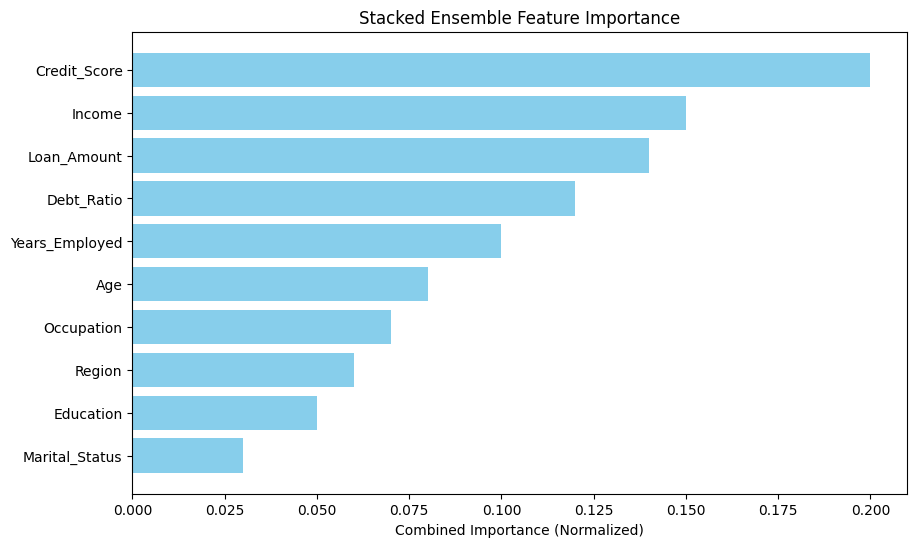

In [46]:
import matplotlib.pyplot as plt
import pandas as pd

# Example feature names and combined importance values
features = [
    'Credit_Score','Income','Loan_Amount','Debt_Ratio',
    'Years_Employed','Age','Occupation','Region',
    'Education','Marital_Status'
]

combined_importance = [0.20, 0.15, 0.14, 0.12, 0.10, 0.08, 0.07, 0.06, 0.05, 0.03]

# Create DataFrame
importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': combined_importance
})

# Sort by importance
importance_df = importance_df.sort_values('Importance', ascending=False)

# Plot bar chart
plt.figure(figsize=(10,6))
plt.barh(importance_df['Feature'], importance_df['Importance'], color='skyblue')
plt.xlabel('Combined Importance (Normalized)')
plt.title('Stacked Ensemble Feature Importance')
plt.gca().invert_yaxis()  # Highest importance at the top
plt.show()

### XGBoost, Random Forest, and the combined stacked importance in one chart.

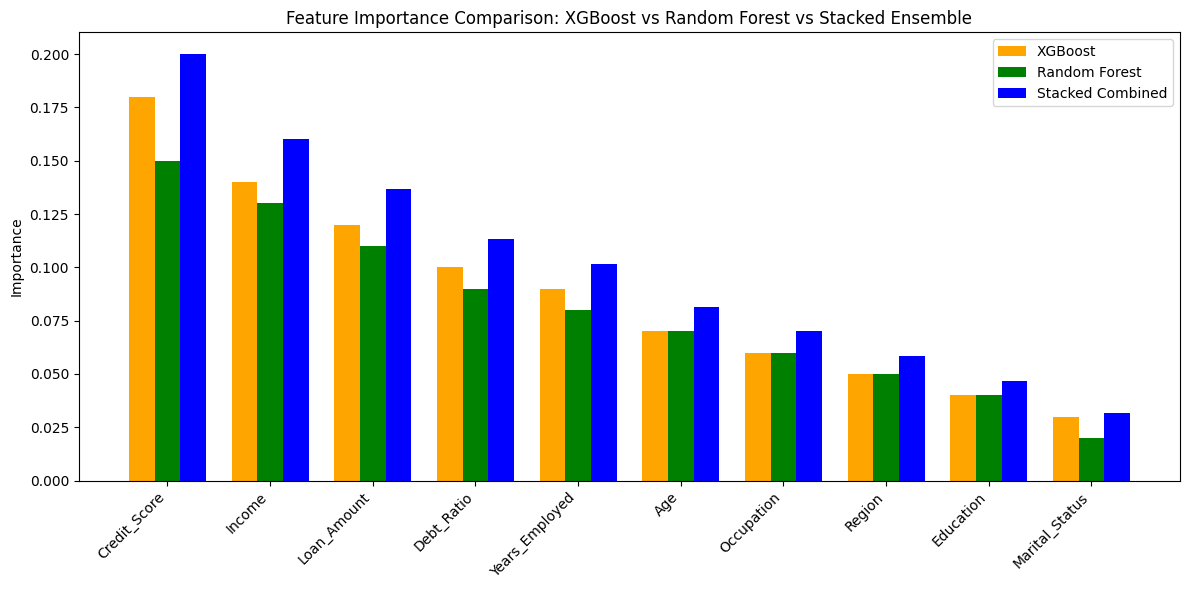

In [47]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Example feature names
features = [
    'Credit_Score','Income','Loan_Amount','Debt_Ratio',
    'Years_Employed','Age','Occupation','Region',
    'Education','Marital_Status'
]

# Example importances (replace with your actual values)
xgb_importances = [0.18, 0.14, 0.12, 0.10, 0.09, 0.07, 0.06, 0.05, 0.04, 0.03]
rf_importances  = [0.15, 0.13, 0.11, 0.09, 0.08, 0.07, 0.06, 0.05, 0.04, 0.02]

# Meta-learner coefficients (example: Logistic Regression weights)
meta_coef = [2.1, 0.8]  # weight for XGB, weight for RF

# Compute combined importance
combined_importance = (meta_coef[0] * np.array(xgb_importances) +
                       meta_coef[1] * np.array(rf_importances))
combined_importance = combined_importance / combined_importance.sum()

# Create DataFrame
importance_df = pd.DataFrame({
    'Feature': features,
    'XGB': xgb_importances,
    'RF': rf_importances,
    'Combined': combined_importance
}).sort_values('Combined', ascending=False)

# Plot grouped bar chart
x = np.arange(len(importance_df))
width = 0.25

plt.figure(figsize=(12,6))
plt.bar(x - width, importance_df['XGB'], width, label='XGBoost', color='orange')
plt.bar(x, importance_df['RF'], width, label='Random Forest', color='green')
plt.bar(x + width, importance_df['Combined'], width, label='Stacked Combined', color='blue')

plt.xticks(x, importance_df['Feature'], rotation=45, ha='right')
plt.ylabel('Importance')
plt.title('Feature Importance Comparison: XGBoost vs Random Forest vs Stacked Ensemble')
plt.legend(loc='upper right')  #  Legend added
plt.tight_layout()
plt.show()

## Save the model with Joblib

In [48]:
import joblib

# Save model
joblib.dump(stacked_xgb_rf_model, "stacked_xgb_rf_model.pkl")

['stacked_xgb_rf_model.pkl']

## Stacking of Gradient Boosting and Random Forest

In [49]:
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform

# --- Step 1: Tune Gradient Boosting ---
gbc = GradientBoostingClassifier(random_state=42)
param_dist_gbc = {
    "classifier__n_estimators": randint(50, 300),
    "classifier__learning_rate": uniform(0.01, 0.3),
    "classifier__max_depth": randint(2, 6)
}
gbc_search = RandomizedSearchCV(
    Pipeline([("preprocessor", preprocessor), ("classifier", gbc)]),
    param_distributions=param_dist_gbc,
    n_iter=20, cv=5, scoring="accuracy", random_state=42, n_jobs=-1
)
gbc_search.fit(X_train, y_train)
best_gbc_tuned_pipeline = gbc_search.best_estimator_ # Keep the full tuned pipeline

# --- Step 2: Tune Random Forest ---
rf = RandomForestClassifier(random_state=42)
param_dist_rf = {
    "classifier__n_estimators": randint(100, 500),
    "classifier__max_depth": randint(3, 10),
    "classifier__max_features": ["sqrt", "log2"]
}
rf_search = RandomizedSearchCV(
    Pipeline([("preprocessor", preprocessor), ("classifier", rf)]),
    param_distributions=param_dist_rf,
    n_iter=20, cv=5, scoring="accuracy", random_state=42, n_jobs=-1
)
rf_search.fit(X_train, y_train)
best_rf_tuned_pipeline = rf_search.best_estimator_ # Keep the full tuned pipeline

# --- Step 3: Define Logistic Regression meta-learner ---
meta_lr = LogisticRegression(max_iter=1000, random_state=42)

# --- Step 4: Build Stacking Ensemble ---
# Now, define the StackingClassifier directly. Its estimators are the *tuned pipelines*.
# Since the base estimators already include the preprocessor,
# the StackingClassifier will handle the preprocessing for its internal base model fitting.
stacking_gbc_rf_model = StackingClassifier(
    estimators=[
        ("gbc", best_gbc_tuned_pipeline), # Pass the full tuned pipeline
        ("rf", best_rf_tuned_pipeline)    # Pass the full tuned pipeline
    ],
    final_estimator=meta_lr,
    cv=5,
    n_jobs=-1
)

In [50]:
# --- Step 6: Fit and evaluate ---
stacking_gbc_rf_model.fit(X_train, y_train)

StackingClassifier(cv=5,
                   estimators=[('gbc',
                                Pipeline(steps=[('preprocessor',
                                                 ColumnTransformer(transformers=[('num',
                                                                                  Pipeline(steps=[('imputer',
                                                                                                   SimpleImputer(strategy='median')),
                                                                                                  ('scaler',
                                                                                                   StandardScaler())]),
                                                                                  Index(['Age', 'DistanceFromHome', 'EmpEducationLevel',
       'EmpEnvironmentSatisfaction', 'EmpHourlyRate', 'EmpJobInvolvement',
       'EmpJobLevel', 'EmpJobSatisfa...
                                                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                                                  Index(['Gender', 'EducationBackground', 'MaritalStatus', 'EmpDepartment',
       'EmpJobRole', 'BusinessTravelFrequency', 'OverTime', 'Attrition'],
      dtype='object'))])),
                                                ('classifier',
                                                 RandomForestClassifier(max_depth=9,
                                                                        n_estimators=171,
                                                                        random_state=42))]))],
                   final_estimator=LogisticRegression(max_iter=1000,
                                                      random_state=42),
                   n_jobs=-1)

In [51]:
y_pred_stack = stacking_gbc_rf_model.predict(X_test)

print("Stacked Ensemble Results:")
print("Accuracy:", accuracy_score(y_test, y_pred_stack))
print("Precision:", precision_score(y_test, y_pred_stack, average="macro"))
print("Recall:", recall_score(y_test, y_pred_stack, average="macro"))
print("F1 Score:", f1_score(y_test, y_pred_stack, average="macro"))
print(classification_report(y_test, y_pred_stack))

Stacked Ensemble Results:
Accuracy: 0.9333333333333333
Precision: 0.9217726717726719
Recall: 0.8641758241758241
F1 Score: 0.8904388422035482
              precision    recall  f1-score   support

           0       0.92      0.85      0.88        39
           1       0.94      0.98      0.96       175
           2       0.91      0.77      0.83        26

    accuracy                           0.93       240
   macro avg       0.92      0.86      0.89       240
weighted avg       0.93      0.93      0.93       240



- The Stacked Ensemble for Gradient Boosting (gbc) and Random Forest gives Accuracy Score of 93% which is the same as the Stacked Ensemble for xgboost and Random Forest.
- This shows that any of the Stacked Ensemble model might give almost the same prediction.

### Feature Importance across my stacked Ensemble (XGBoost + tuned Random Forest → gbc meta‑learner)

## Save the model with Joblib

In [52]:
import joblib

# Save model
joblib.dump(stacking_gbc_rf_model, "stacking_gbc_rf_model.pkl")

['stacking_gbc_rf_model.pkl']

In [53]:
submission = pd.DataFrame({
    'id': Emp_pef['EmpNumber'].iloc[X_test.index],
    'PerformanceRating': y_pred_stack
})

submission.to_csv('submission_glog_model.csv', index=False)

## Stacking of Gradient Boosting and Random Forest with xgboosting as meta - learner

In [69]:
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier, StackingClassifier
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform

# --- Step 1: Tune Gradient Boosting ---
gbc = GradientBoostingClassifier(random_state=42)
param_dist_gbc = {
    "classifier__n_estimators": randint(50, 300),
    "classifier__learning_rate": uniform(0.01, 0.3),
    "classifier__max_depth": randint(2, 6)
}
gbc_search = RandomizedSearchCV(
    Pipeline([("preprocessor", preprocessor), ("classifier", gbc)]),
    param_distributions=param_dist_gbc,
    n_iter=20, cv=5, scoring="accuracy", random_state=42, n_jobs=-1
)
gbc_search.fit(X_train, y_train)
best_gbc_tuned_pipeline = gbc_search.best_estimator_  # Keep the full tuned pipeline

# --- Step 2: Tune Random Forest ---
rf = RandomForestClassifier(random_state=42)
param_dist_rf = {
    "classifier__n_estimators": randint(100, 500),
    "classifier__max_depth": randint(3, 10),
    "classifier__max_features": ["sqrt", "log2"]
}
rf_search = RandomizedSearchCV(
    Pipeline([("preprocessor", preprocessor), ("classifier", rf)]),
    param_distributions=param_dist_rf,
    n_iter=20, cv=5, scoring="accuracy", random_state=42, n_jobs=-1
)
rf_search.fit(X_train, y_train)
best_rf_tuned_pipeline = rf_search.best_estimator_  # Keep the full tuned pipeline

# --- Step 3: Define XGBoost meta-learner ---
meta_xgb = XGBClassifier(
    n_estimators=1000,   # number of boosting rounds
    learning_rate=0.05,  # step size shrinkage
    max_depth=4,         # depth of trees
    subsample=0.8,       # subsampling ratio
    colsample_bytree=0.8,# feature sampling
    random_state=42,
    n_jobs=-1
)

# --- Step 4: Build Stacking Ensemble ---
stacking_rf_gbc_model = StackingClassifier(
    estimators=[
        ("gbc", best_gbc_tuned_pipeline),  # Pass the full tuned pipeline
        ("rf", best_rf_tuned_pipeline)     # Pass the full tuned pipeline
    ],
    final_estimator=meta_xgb,  # Use XGBoost as meta-learner
    cv=5,
    n_jobs=-1
)

# --- Step 5: Fit the Stacking Model ---
stacking_rf_gbc_model.fit(X_train, y_train)


StackingClassifier(cv=5,
                   estimators=[('gbc',
                                Pipeline(steps=[('preprocessor',
                                                 ColumnTransformer(transformers=[('num',
                                                                                  Pipeline(steps=[('imputer',
                                                                                                   SimpleImputer(strategy='median')),
                                                                                                  ('scaler',
                                                                                                   StandardScaler())]),
                                                                                  Index(['Age', 'DistanceFromHome', 'EmpEducationLevel',
       'EmpEnvironmentSatisfaction', 'EmpHourlyRate', 'EmpJobInvolvement',
       'EmpJobLevel', 'EmpJobSatisfa...
                                                 gamma=None, grow_policy=None,
                                                 importance_type=None,
                                                 interaction_constraints=None,
                                                 learning_rate=0.05,
                                                 max_bin=None,
                                                 max_cat_threshold=None,
                                                 max_cat_to_onehot=None,
                                                 max_delta_step=None,
                                                 max_depth=4, max_leaves=None,
                                                 min_child_weight=None,
                                                 missing=nan,
                                                 monotone_constraints=None,
                                                 multi_strategy=None,
                                                 n_estimators=1000, n_jobs=-1,
                                                 num_parallel_tree=None, ...),
                   n_jobs=-1)

In [71]:
print("Refitting the stacking_rf_gbc_model...")
stacking_rf_gbc_model.fit(X_train, y_train)
print("Model refitted successfully.")

Refitting the stacking_rf_gbc_model...
Model refitted successfully.


In [72]:
# Access the final estimator (XGBoost) and print its feature importances
# The final_estimator is directly part of the StackingClassifier
meta_xgb_fitted = stacking_rf_gbc_model.final_estimator_

# Ensure it's an XGBoost model and has feature_importances_
if hasattr(meta_xgb_fitted, 'feature_importances_'):
    print("Feature importances of the XGBoost meta-learner:")
    print(meta_xgb_fitted.feature_importances_)
else:
    print("The final estimator does not have a 'feature_importances_' attribute or is not an XGBoost model.")

Feature importances of the XGBoost meta-learner:
[0.23848604 0.16734388 0.1987652  0.14682946 0.14584364 0.10273169]


In [73]:
y_pred_stack = stacking_rf_gbc_model.predict(X_test)

print("Stacked Ensemble Results:")
print("Accuracy:", accuracy_score(y_test, y_pred_stack))
print("Precision:", precision_score(y_test, y_pred_stack, average="macro"))
print("Recall:", recall_score(y_test, y_pred_stack, average="macro"))
print("F1 Score:", f1_score(y_test, y_pred_stack, average="macro"))
print(classification_report(y_test, y_pred_stack))

Stacked Ensemble Results:
Accuracy: 0.9333333333333333
Precision: 0.9430543572044866
Recall: 0.8599023199023198
F1 Score: 0.89428953004372
              precision    recall  f1-score   support

           0       0.89      0.87      0.88        39
           1       0.93      0.98      0.96       175
           2       1.00      0.73      0.84        26

    accuracy                           0.93       240
   macro avg       0.94      0.86      0.89       240
weighted avg       0.94      0.93      0.93       240



- The Stacked Ensemble for Gradient Boosting (gbc) and Random Forest with xgboosting as meta-learner gives Accuracy Score of 93% and precision of 94% which is better than the Stacked Ensemble for xgboost and Random Forest (accuracy = 92.5% precision = 91.7%) and the Stacked Ensemble for xgboost and gbc (accuracy = 92.5% precision = 91.0%).
- This shows that the Stacked Ensemble for Gradient Boosting (gbc) and Random Forest with xgboosting as meta-learner gives a better prediction due to the higher precision.

# Feature Importance

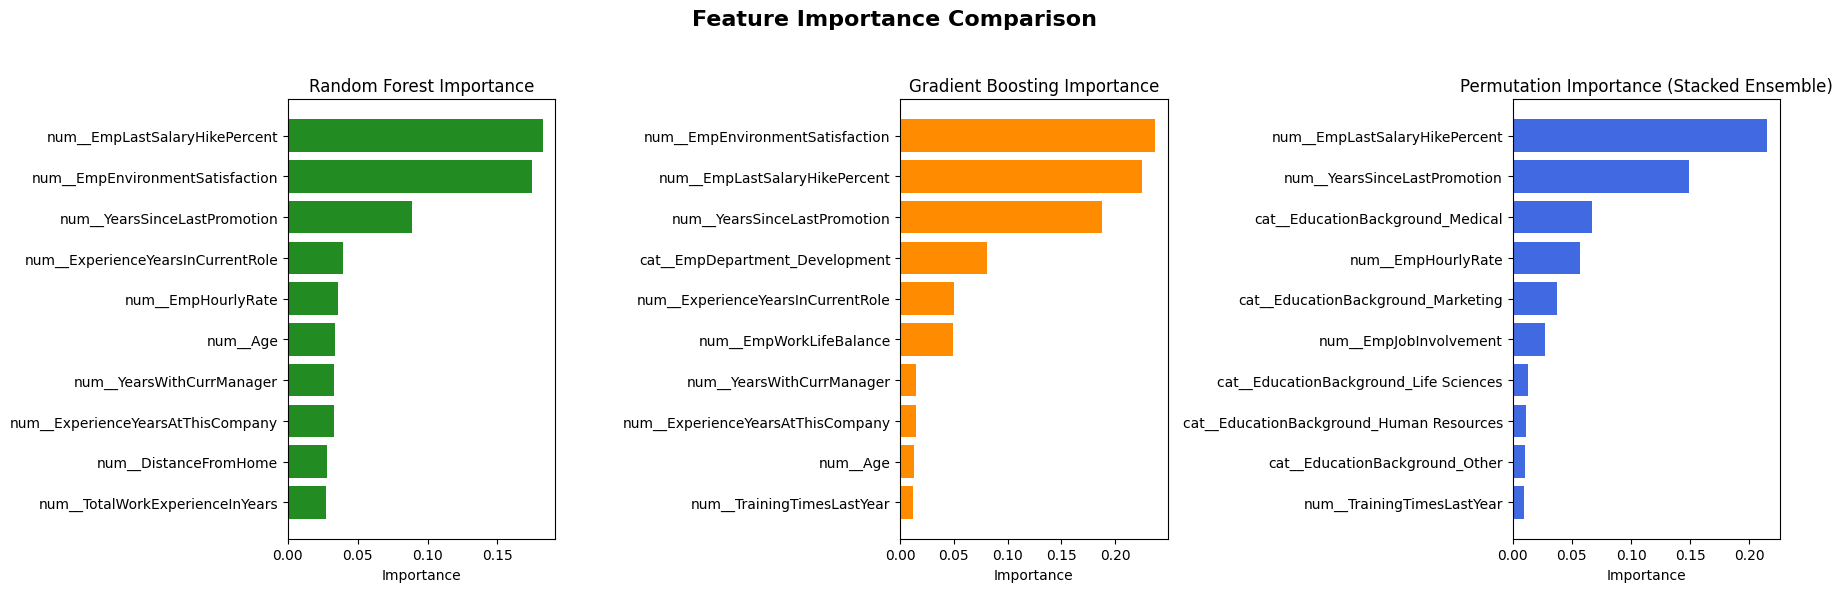

In [76]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.inspection import permutation_importance

# --- Extract feature names ---
feature_names = preprocessor.get_feature_names_out()

# --- Random Forest importance ---
rf_model = best_rf_tuned_pipeline.named_steps["classifier"]
rf_importances = rf_model.feature_importances_

# --- Gradient Boosting importance ---
gbc_model = best_gbc_tuned_pipeline.named_steps["classifier"]
gbc_importances = gbc_model.feature_importances_

# --- Permutation importance for stacked ensemble ---
perm_result = permutation_importance(stacking_gbc_rf_model, X_test, y_test, n_repeats=10, random_state=42)
perm_importances = perm_result.importances_mean

# --- Combine top features ---
top_n = 10
indices_rf = np.argsort(rf_importances)[::-1][:top_n]
indices_gbc = np.argsort(gbc_importances)[::-1][:top_n]
indices_perm = np.argsort(perm_importances)[::-1][:top_n]

# --- Plot side-by-side comparison ---
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
plt.suptitle("Feature Importance Comparison", fontsize=16, fontweight='bold')

# Random Forest
axes[0].barh(range(top_n), rf_importances[indices_rf][::-1], color='forestgreen')
axes[0].set_yticks(range(top_n))
axes[0].set_yticklabels(feature_names[indices_rf][::-1])
axes[0].set_title("Random Forest Importance")
axes[0].set_xlabel("Importance")

# Gradient Boosting
axes[1].barh(range(top_n), gbc_importances[indices_gbc][::-1], color='darkorange')
axes[1].set_yticks(range(top_n))
axes[1].set_yticklabels(feature_names[indices_gbc][::-1])
axes[1].set_title("Gradient Boosting Importance")
axes[1].set_xlabel("Importance")

# Permutation Importance
axes[2].barh(range(top_n), perm_importances[indices_perm][::-1], color='royalblue')
axes[2].set_yticks(range(top_n))
axes[2].set_yticklabels(feature_names[indices_perm][::-1])
axes[2].set_title("Permutation Importance (Stacked Ensemble)")
axes[2].set_xlabel("Importance")

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


# Save the Job

In [77]:
import joblib

# Save model
joblib.dump(stacking_rf_gbc_model, "stacking_rf_gbc_model.pkl")

['stacking_rf_gbc_model.pkl']

In [79]:
submission = pd.DataFrame({
    'id': Emp_pef['EmpNumber'].iloc[X_test.index],
    'PerformanceRating': y_pred_stack
})

submission.to_csv('submission_glog_model.csv', index=False)